<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-04-09 22:24:19--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.66’

survey-results-publ 100%[===================>] 201.62M  39.4MB/s    in 5.4s    

2026-04-09 22:24:27 (37.4 MB/s) - ‘survey-results-public.sqlite.66’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
!pip install seaborn 

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


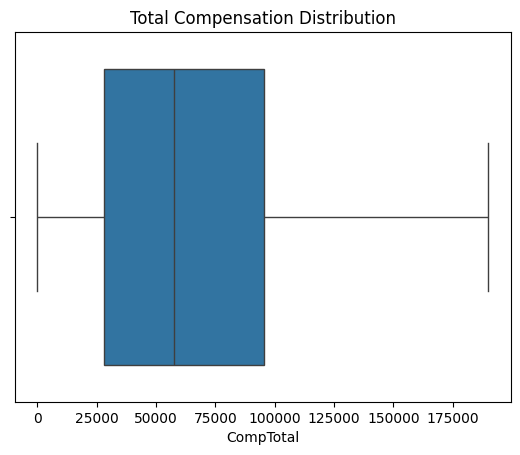

In [9]:
# your code goes here
query = """
SELECT CompTotal FROM main
where CompTotal between 0 and 190000 and CompTotal is not null
group by CompTotal
"""
df_comptotal = pd.read_sql_query(query, conn)
sns.boxplot(x=df_comptotal['CompTotal'])
plt.title('Total Compensation Distribution')
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


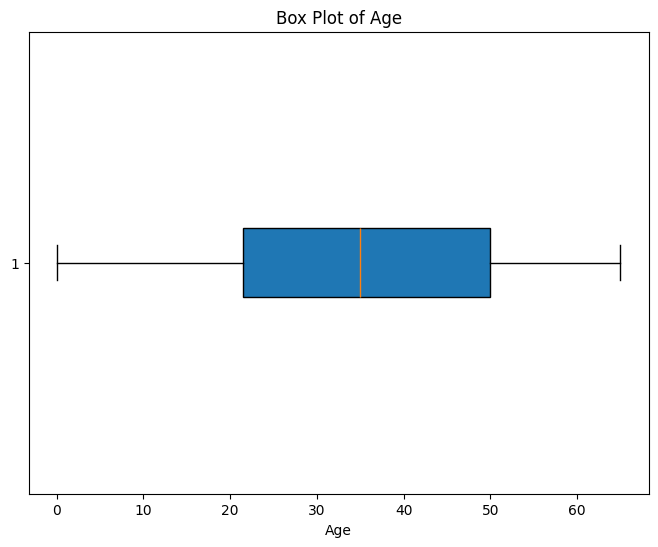

In [10]:
# your code goes here
query = """
SELECT 
    CAST(SUBSTR(Age, 1, INSTR(Age, ' ') - 1) AS INTEGER) AS NumericAge,
    COUNT(*) AS Frequency
FROM main
WHERE Age IS NOT NULL
GROUP BY NumericAge
ORDER BY NumericAge;
"""
df_age = pd.read_sql_query(query, conn)
df_age.head(6)
plt.figure(figsize=(8, 6))
plt.boxplot(df_age['NumericAge'].dropna(), vert=False, patch_artist=True)
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


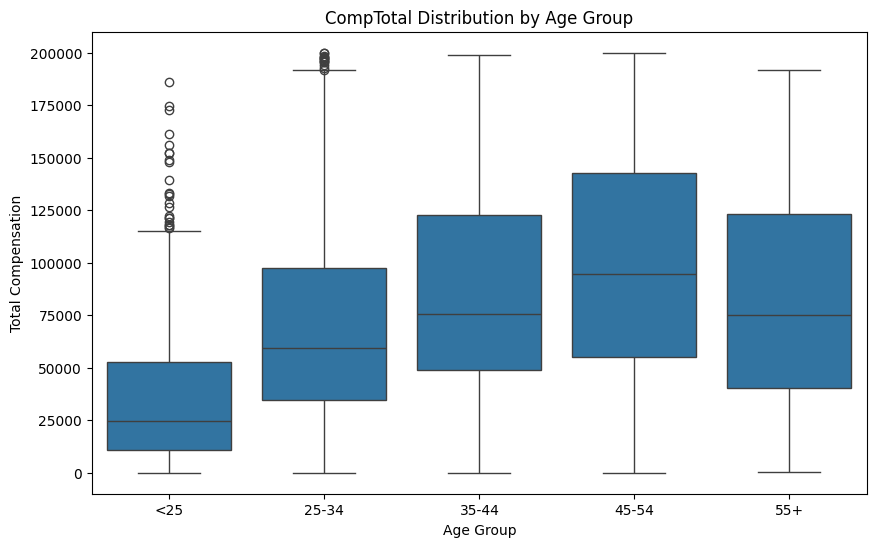

In [11]:
query = """
SELECT CompTotal,
       CASE 
           WHEN Age < 25 THEN '<25'
           WHEN Age BETWEEN 25 AND 34 THEN '25-34'
           WHEN Age BETWEEN 35 AND 44 THEN '35-44'
           WHEN Age BETWEEN 45 AND 54 THEN '45-54'
           ELSE '55+' 
       END AS AgeGroup
FROM main
where CompTotal between 0 and 200000 and CompTotal is not null
group by CompTotal
"""
df = pd.read_sql_query(query, conn)
plt.figure(figsize=(10, 6))
sns.boxplot(x='AgeGroup', y='CompTotal', data=df, 
            order=['<25', '25-34', '35-44', '45-54', '55+'])
plt.title('CompTotal Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Compensation')
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


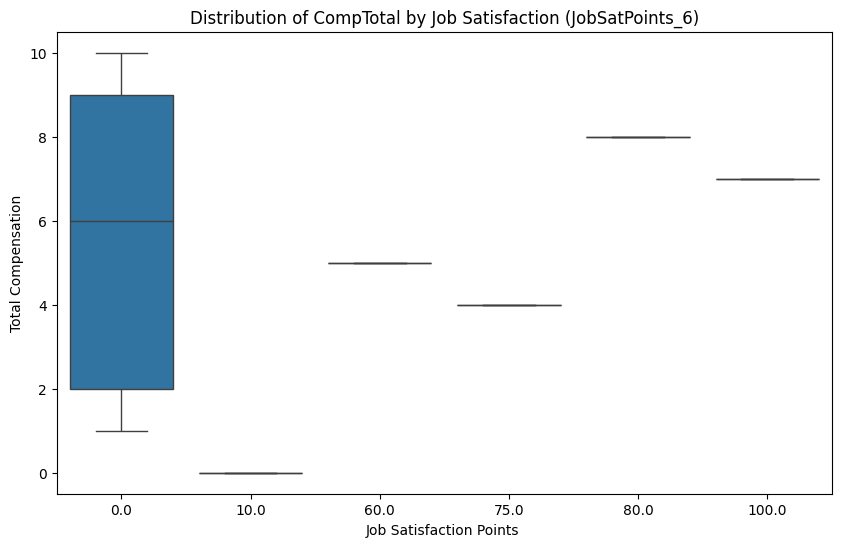

In [12]:
query = """
SELECT CompTotal, JobSatPoints_6 FROM main
where CompTotal between 0 and 190000 and CompTotal is not null and JobSatPoints_6 between 0 and 100 and JobSatPoints_6 is not null
group by CompTotal
"""
df = pd.read_sql_query(query, conn)
df = df.dropna(subset=['CompTotal', 'JobSatPoints_6']).head(10)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='JobSatPoints_6', y='CompTotal')
plt.title('Distribution of CompTotal by Job Satisfaction (JobSatPoints_6)')
plt.xlabel('Job Satisfaction Points ')
plt.ylabel('Total Compensation')
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


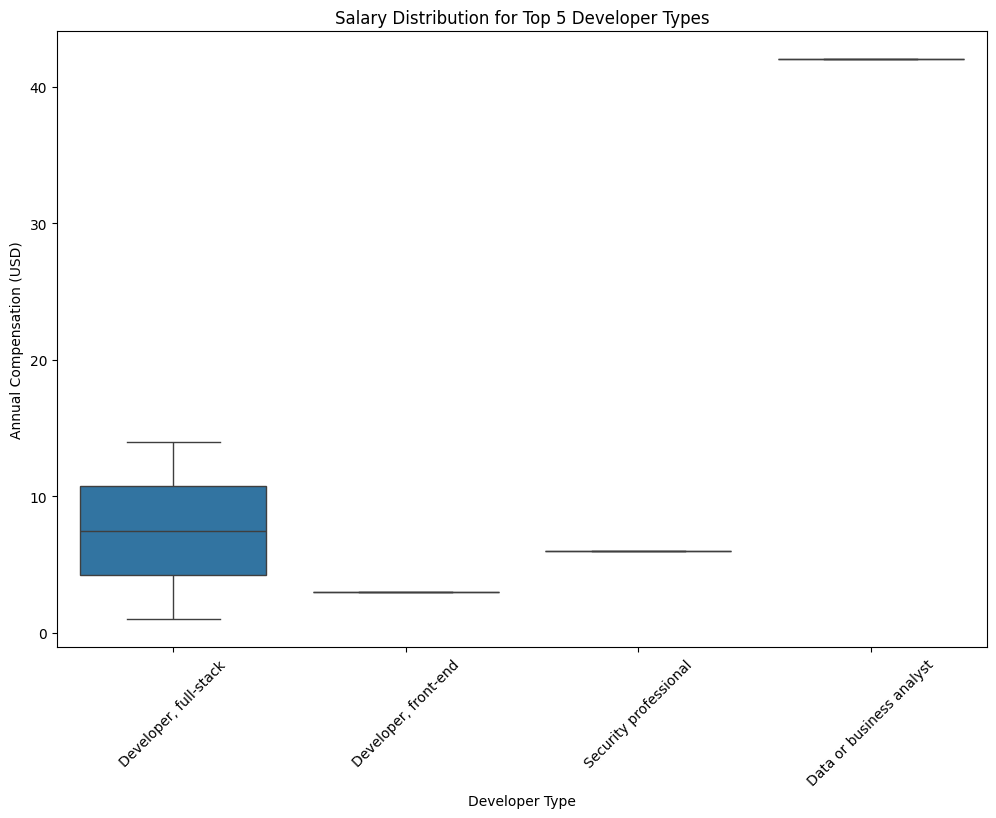

In [13]:
query = """
SELECT DevType, ConvertedCompYearly
FROM main
Where ConvertedCompYearly between 0 and 17000000 and CompTotal is not null
GROUP BY Country 
ORDER BY ConvertedCompYearly
LIMIT 5
"""
df = pd.read_sql_query(query, conn)
top_5_types = df['DevType'].value_counts().nlargest(5).index
df_top_5 = df[df['DevType'].isin(top_5_types)]
plt.figure(figsize=(12, 8))
sns.boxplot(x='DevType', y='ConvertedCompYearly', data=df_top_5)
plt.title('Salary Distribution for Top 5 Developer Types')
plt.xlabel('Developer Type')
plt.ylabel('Annual Compensation (USD)')
plt.xticks(rotation=45)
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


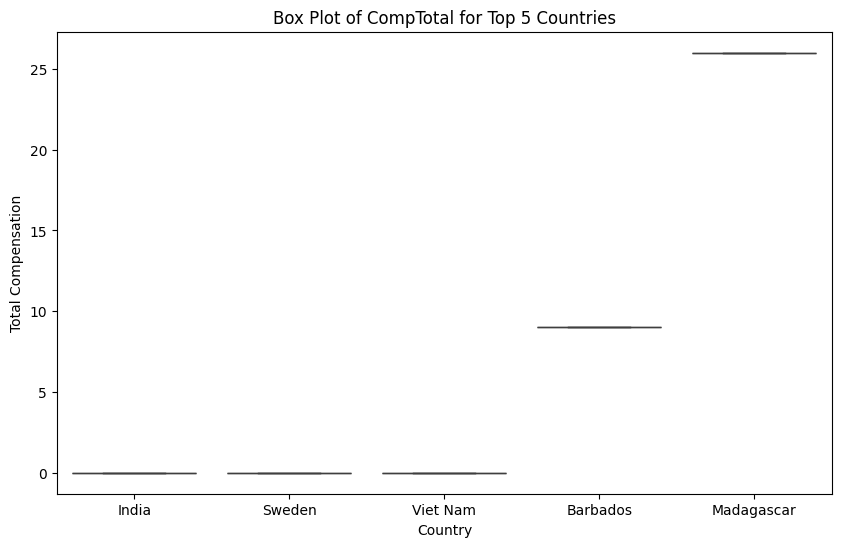

In [14]:
query = """
SELECT CompTotal, Country
FROM main
Where CompTotal between 0 and 190000 and CompTotal is not null
GROUP BY Country 
ORDER BY CompTotal
LIMIT 5
"""
df = pd.read_sql_query(query, conn)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Country', y='CompTotal', data=df)
plt.title('Box Plot of CompTotal for Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Total Compensation')
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


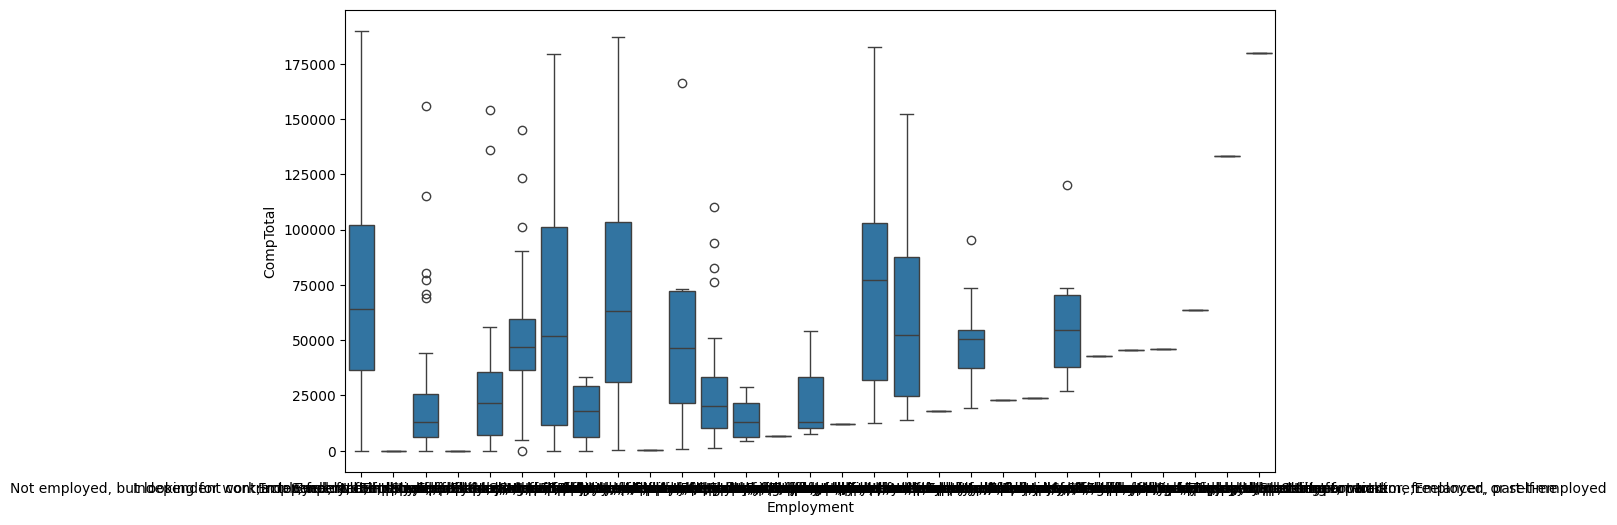

In [15]:
query = """
SELECT CompTotal, Employment FROM main
where CompTotal between 0 and 190000 and CompTotal is not null
group by CompTotal
"""
df = pd.read_sql_query(query, conn)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Employment', y='CompTotal')
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


/tmp/ipykernel_2674/3655797512.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='JobSatPoints_6', y='YearsCodePro', palette='viridis')


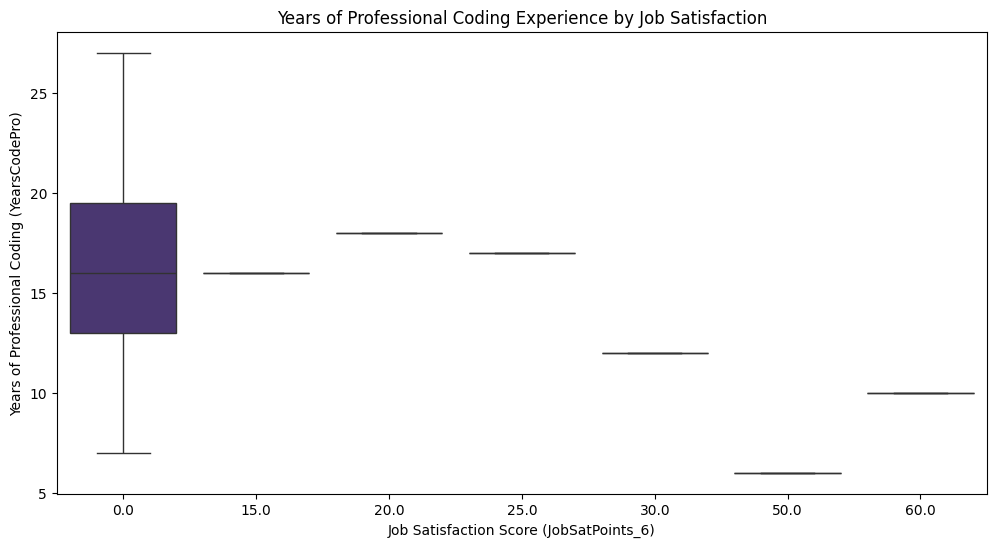

In [16]:
query = "SELECT YearsCodePro, JobSatPoints_6 FROM main"
df = pd.read_sql_query(query, conn)
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df = df.dropna(subset=['YearsCodePro', 'JobSatPoints_6']).head(10)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='JobSatPoints_6', y='YearsCodePro', palette='viridis')
plt.title('Years of Professional Coding Experience by Job Satisfaction')
plt.xlabel('Job Satisfaction Score (JobSatPoints_6)')
plt.ylabel('Years of Professional Coding (YearsCodePro)')
plt.show()


### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [17]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
